In [0]:
# Silver path from your pipeline
silver_adls = "abfss://silver@sdfgsdfgs456ghh.dfs.core.windows.net/earthquake_events_silver/"

# Load into a Spark DataFrame
df = spark.read.parquet(silver_adls)

# Show a few rows
df.show(5)

+-------------+-----------------+----------------+---------+--------------------+--------------------+---+----+-------+--------------------+--------------------+
|           id|        longitude|        latitude|elevation|               title|   place_description|sig| mag|magType|                time|             updated|
+-------------+-----------------+----------------+---------+--------------------+--------------------+---+----+-------+--------------------+--------------------+
|   pr71508438|-66.7823333333333|18.0391666666667|     15.6|M 2.1 - 2 km NNE ...|2 km NNE of Guaya...| 66|2.07|     md|2026-02-21 23:55:...|2026-02-22 00:33:...|
|   us6000sapq|         166.4871|        -46.2323|   42.088|M 4.9 - 118 km W ...|118 km W of River...|370| 4.9|    mww|2026-02-21 23:55:...|2026-02-22 00:53:...|
|aka2026drlmyc|         -154.944|          57.291|     53.4|M 2.1 - 42 km SW ...|42 km SW of Karlu...| 68| 2.1|     ml|2026-02-21 23:52:...| 2026-02-21 23:54:13|
|   pr71508433|         -64.

In [0]:
# Sjekk schema
df.printSchema()

# Tell antall rader
df.count()

# Sjekk for nuller
from pyspark.sql.functions import col, sum
df.select([sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]).show()

root
 |-- id: string (nullable = true)
 |-- longitude: double (nullable = true)
 |-- latitude: double (nullable = true)
 |-- elevation: double (nullable = true)
 |-- title: string (nullable = true)
 |-- place_description: string (nullable = true)
 |-- sig: long (nullable = true)
 |-- mag: double (nullable = true)
 |-- magType: string (nullable = true)
 |-- time: timestamp (nullable = true)
 |-- updated: timestamp (nullable = true)

+---+---------+--------+---------+-----+-----------------+---+---+-------+----+-------+
| id|longitude|latitude|elevation|title|place_description|sig|mag|magType|time|updated|
+---+---------+--------+---------+-----+-----------------+---+---+-------+----+-------+
|  0|        0|       0|        0|    0|                0|  0|  0|      0|   0|      0|
+---+---------+--------+---------+-----+-----------------+---+---+-------+----+-------+



In [0]:
# Deskriptiv statistikk for numeriske kolonner
df.describe(["mag", "sig", "elevation"]).show()

# Se antall jordskjelv per dag
from pyspark.sql.functions import to_date
df.groupBy(to_date(col("time")).alias("date")).count().orderBy("date").show()

+-------+------------------+------------------+------------------+
|summary|               mag|               sig|         elevation|
+-------+------------------+------------------+------------------+
|  count|               705|               705|               705|
|   mean|1.8197867103220184| 78.65957446808511|26.878870109121987|
| stddev| 1.308014679443133|108.06637466022922|  68.3898308584761|
|    min|             -0.81|                 0|             -2.31|
|    max|               6.4|               631|           605.972|
+-------+------------------+------------------+------------------+

+----------+-----+
|      date|count|
+----------+-----+
|2026-02-14|  448|
|2026-02-21|  257|
+----------+-----+



In [0]:
# Plot jordskjelv per dag
display(df.groupBy(to_date(col("time")).alias("date")).count().orderBy("date")) 

# # Plot magnitude vs. elevation
# display(df.select("mag", "elevation"))

date,count
2026-02-14,448
2026-02-21,257


In [0]:
# Konverter til Pandas
df_pd = df.toPandas()

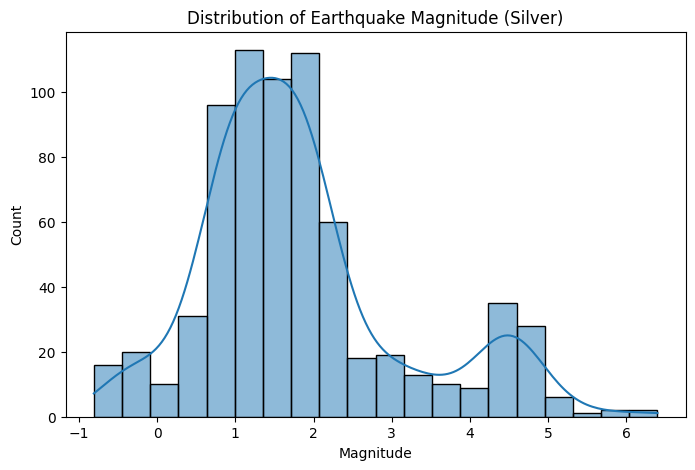

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_pd['mag'], bins=20, kde=True)
plt.title("Distribution of Earthquake Magnitude (Silver)")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.show()

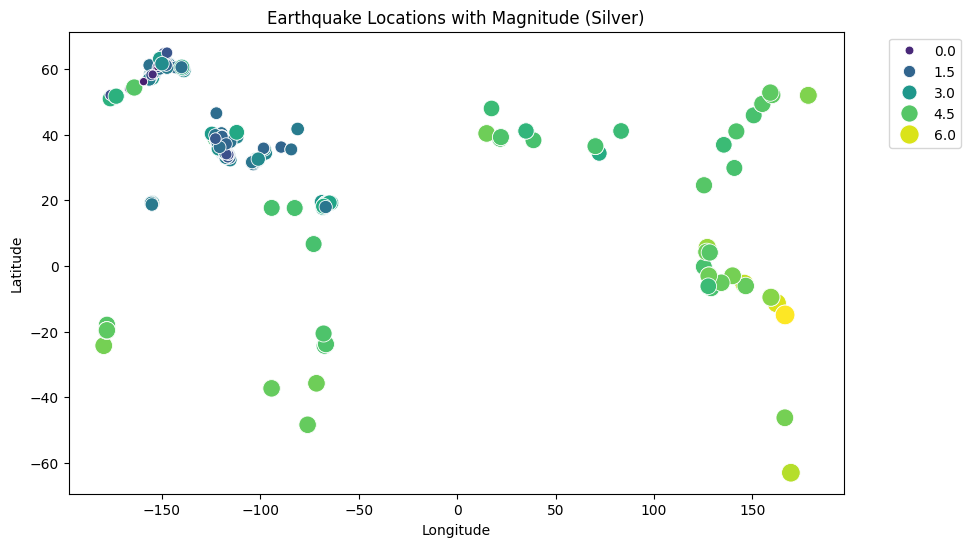

In [0]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='longitude', y='latitude', size='mag', hue='mag', palette='viridis', sizes=(20,200), data=df_pd)
plt.title("Earthquake Locations with Magnitude (Silver)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()